<a href="https://colab.research.google.com/github/Gowtham13042007/cron_job/blob/main/ml4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Linear Regression


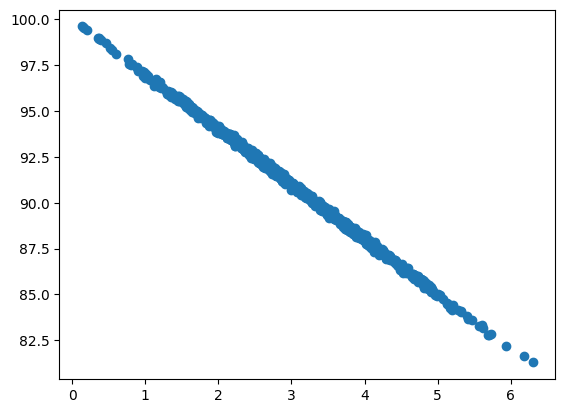

In [7]:
import numpy as np
import matplotlib.pyplot as plt

pagespeeds=np.random.normal(3.0,1.0,1000)
purchaseamount=100-(pagespeeds*3+np.random.normal(0,0.1,1000))
plt.scatter(pagespeeds,purchaseamount)

In [8]:
from scipy import stats
slope,intercept,r_value,p_value,std_err=stats.linregress(pagespeeds,purchaseamount)
print(slope,intercept,r_value,p_value,std_err)

-2.999237549926998 100.00243148589766 -0.9994733877686649 0.0 0.003082319431977195


In [9]:
print(r_value**2)

0.998947052857772


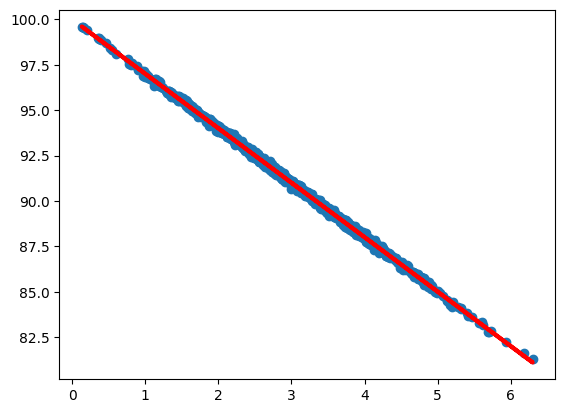

In [10]:
def predict(x):
  return slope*x+intercept

fitline=predict(pagespeeds)
plt.scatter(pagespeeds,purchaseamount)
plt.plot(pagespeeds,fitline,c='r',linewidth=3)
plt.show()

Polynomial Regression

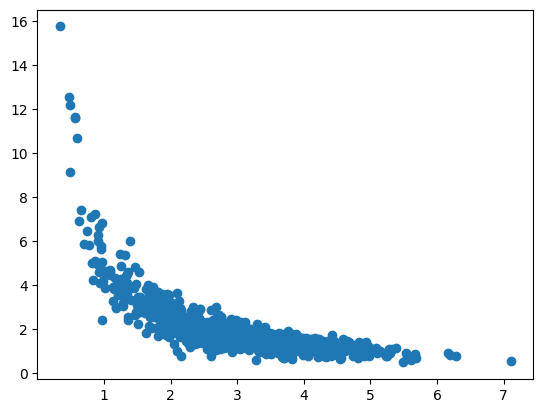

In [15]:
np.random.seed(2)
pagespeeds=np.random.normal(3.0,1.0,1000)
purchaseamount=np.random.normal(5,1,1000)/pagespeeds
plt.scatter(pagespeeds,purchaseamount)

In [22]:
p4=np.poly1d(np.polyfit(pagespeeds,purchaseamount,10))
print(p4)

            10            9           8          7         6         5
-0.0002271 x  + 0.006993 x - 0.08736 x + 0.5464 x - 1.521 x - 1.137 x
          4         3         2
 + 22.24 x - 72.28 x + 116.2 x - 98.03 x + 38.8


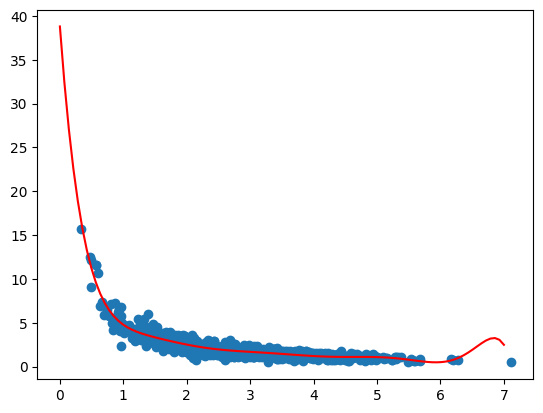

In [23]:
xp=np.linspace(0,7,100)
plt.scatter(pagespeeds,purchaseamount)
plt.plot(xp,p4(xp),c='r')
plt.show()

In [21]:
from sklearn.metrics import r2_score
r2=r2_score(purchaseamount,p4(pagespeeds))
print(r2)

0.8293766396303073


Multiple Regression

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
df=pd.read_excel('http://cdn.sundog-soft.com/Udemy/DataScience/cars.xls')
df.tail()

,Price,Mileage,Make,Model,Trim,Type,Cylinder,Liter,Doors,Cruise,Sound,Leather
799,16507.070267,16229,Saturn,L Series,L300 Sedan 4D,Sedan,6,3.0,4,1,0,0
800,16175.957604,19095,Saturn,L Series,L300 Sedan 4D,Sedan,6,3.0,4,1,1,0
801,15731.132897,20484,Saturn,L Series,L300 Sedan 4D,Sedan,6,3.0,4,1,1,0
802,15118.893228,25979,Saturn,L Series,L300 Sedan 4D,Sedan,6,3.0,4,1,1,0
803,13585.636802,35662,Saturn,L Series,L300 Sedan 4D,Sedan,6,3.0,4,1,0,0


[    0 10000 20000 30000 40000 50000 60000]
                     Mileage         Price
Mileage                                   
(0, 10000]       5588.629630  24096.714451
(10000, 20000]  15898.496183  21955.979607
(20000, 30000]  24114.407104  20278.606252
(30000, 40000]  33610.338710  19463.670267
(40000, 50000]  43159.200000  30802.690000
(50000, 60000]  50387.000000  22244.876553


/tmp/ipykernel_6228/843967026.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  groups=df1.groupby(pd.cut(df1['Mileage'],bins)).mean()


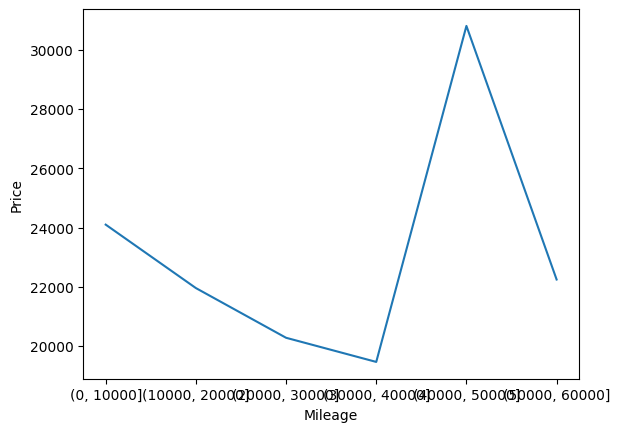

In [40]:
df1=df[['Mileage','Price']]
bins=np.arange(0,70000,10000)  # start stop step
print(bins)
groups=df1.groupby(pd.cut(df1['Mileage'],bins)).mean()
print(groups)
plt.plot(groups.index.astype(str), groups['Price'])
plt.xlabel('Mileage')
plt.ylabel('Price')
plt.show()

In [49]:
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler
x=df[['Mileage','Cylinder','Doors']]
y=df['Price']
x[['Mileage','Cylinder','Doors']]=StandardScaler().fit_transform(x[['Mileage','Cylinder','Doors']])  # standardise to mean is 0 and standard deviation is 1
x=sm.add_constant(x)  # add a constant column to our model so we cann have a y intercept
print(x)
est=sm.OLS(y,x).fit()
print(est.summary())

     const   Mileage  Cylinder     Doors
0      1.0 -1.417485   0.52741  0.556279
1      1.0 -1.305902   0.52741  0.556279
2      1.0 -0.810128   0.52741  0.556279
3      1.0 -0.426058   0.52741  0.556279
4      1.0  0.000008   0.52741  0.556279
..     ...       ...       ...       ...
799    1.0 -0.439853   0.52741  0.556279
800    1.0 -0.089966   0.52741  0.556279
801    1.0  0.079605   0.52741  0.556279
802    1.0  0.750446   0.52741  0.556279
803    1.0  1.932565   0.52741  0.556279

[804 rows x 4 columns]
                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.360
Model:                            OLS   Adj. R-squared:                  0.358
Method:                 Least Squares   F-statistic:                     150.0
Date:                Sun, 10 May 2026   Prob (F-statistic):           3.95e-77
Time:                        05:25:59   Log-Likelihood:                -8356.7
No. Observ

/tmp/ipykernel_6228/2124307836.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  x[['Mileage','Cylinder','Doors']]=StandardScaler().fit_transform(x[['Mileage','Cylinder','Doors']])  # standardise to mean is 0 and standard deviation is 1


In [46]:
y.groupby(df.Doors).mean()

,Price
Doors,
2,23807.135520
4,20580.670749


In [53]:
df.head()


,Price,Mileage,Make,Model,Trim,Type,Cylinder,Liter,Doors,Cruise,Sound,Leather
0,17314.103129,8221,Buick,Century,Sedan 4D,Sedan,6,3.1,4,1,1,1
1,17542.036083,9135,Buick,Century,Sedan 4D,Sedan,6,3.1,4,1,1,0
2,16218.847862,13196,Buick,Century,Sedan 4D,Sedan,6,3.1,4,1,1,0
3,16336.913140,16342,Buick,Century,Sedan 4D,Sedan,6,3.1,4,1,0,0
4,16339.170324,19832,Buick,Century,Sedan 4D,Sedan,6,3.1,4,1,0,1
